# Lab 13: Finding How The Data Is Distributed
## IBM Data Analytics Capstone Project 
### Objective: Examine data structure, visualize distributions, analyze trends in developer experience, tools, job satisfaction and remote work

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Load the dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (65437, 114)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [2]:
# Column names, data types and summary
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes.value_counts())
print("\nColumn Names:")
print(df.columns.tolist())
print("\nBasic Info:")
df.describe()

Shape: (65437, 114)

Data Types:
object     100
float64     13
int64        1
Name: count, dtype: int64

Column Names:
['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmi

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


In [3]:
# Identify and handle missing values
print("Missing values in key columns:")
key_cols = ['Employment', 'JobSat', 'RemoteWork', 
            'YearsCodePro', 'Age', 'CompTotal']
for col in key_cols:
    print(f"  {col}: {df[col].isnull().sum()}")

# Handle missing values
df['RemoteWork'] = df['RemoteWork'].fillna(df['RemoteWork'].mode()[0])
df['Employment'] = df['Employment'].fillna(df['Employment'].mode()[0])
df['JobSat'] = df['JobSat'].fillna(df['JobSat'].median())
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df['YearsCodePro'] = df['YearsCodePro'].fillna(df['YearsCodePro'].median())
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')
df['CompTotal'] = df['CompTotal'].fillna(df['CompTotal'].median())

print("\nAfter handling - Missing values:")
for col in key_cols:
    print(f"  {col}: {df[col].isnull().sum()}")
print("Missing values handled!")

Missing values in key columns:
  Employment: 0
  JobSat: 36311
  RemoteWork: 10631
  YearsCodePro: 13827
  Age: 0
  CompTotal: 31697

After handling - Missing values:
  Employment: 0
  JobSat: 0
  RemoteWork: 0
  YearsCodePro: 0
  Age: 0
  CompTotal: 0
Missing values handled!


In [4]:
# Value counts for key columns
print("Employment distribution (top 5):")
print(df['Employment'].value_counts().head(5))

print("\nJobSat distribution:")
print(df['JobSat'].value_counts().sort_index())

print("\nYearsCodePro summary:")
print(df['YearsCodePro'].describe())

Employment distribution (top 5):
Employment
Employed, full-time                                                         39041
Independent contractor, freelancer, or self-employed                         4846
Student, full-time                                                           4709
Employed, full-time;Independent contractor, freelancer, or self-employed     3557
Not employed, but looking for work                                           2341
Name: count, dtype: int64

JobSat distribution:
JobSat
0.0       311
1.0       276
2.0       772
3.0      1165
4.0      1130
5.0      1956
6.0      3751
7.0     42690
8.0      7509
9.0      3626
10.0     2251
Name: count, dtype: int64

YearsCodePro summary:
count    65437.000000
mean        10.039091
std          7.800656
min          1.000000
25%          5.000000
50%          8.000000
75%         12.000000
max         50.000000
Name: YearsCodePro, dtype: float64


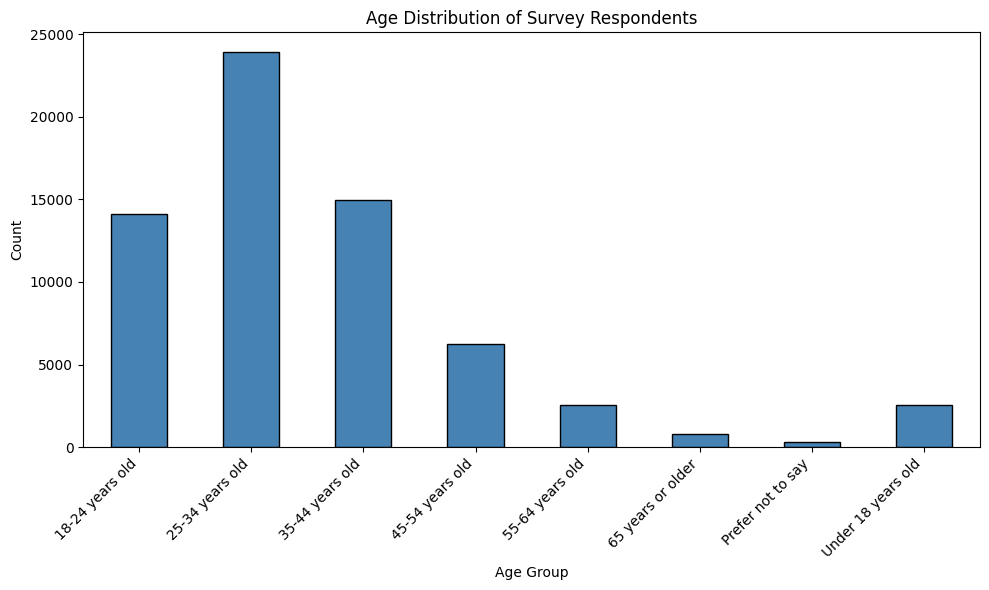

 Age histogram saved!


In [5]:
# Histogram for Age distribution
plt.figure(figsize=(10, 6))
df['Age'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Age Distribution of Survey Respondents')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Age histogram saved!")

In [6]:
# Calculate IQR for CompTotal
Q1 = df['CompTotal'].quantile(0.25)
Q3 = df['CompTotal'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("CompTotal IQR Analysis:")
print(f"  Q1: {Q1:,.0f}")
print(f"  Q3: {Q3:,.0f}")
print(f"  IQR: {IQR:,.0f}")
print(f"  Lower Bound: {lower_bound:,.0f}")
print(f"  Upper Bound: {upper_bound:,.0f}")
outliers = df[(df['CompTotal'] < lower_bound) | (df['CompTotal'] > upper_bound)]
print(f"  Number of outliers: {len(outliers):,}")

CompTotal IQR Analysis:
  Q1: 103,000
  Q3: 114,000
  IQR: 11,000
  Lower Bound: 86,500
  Upper Bound: 130,500
  Number of outliers: 28,132


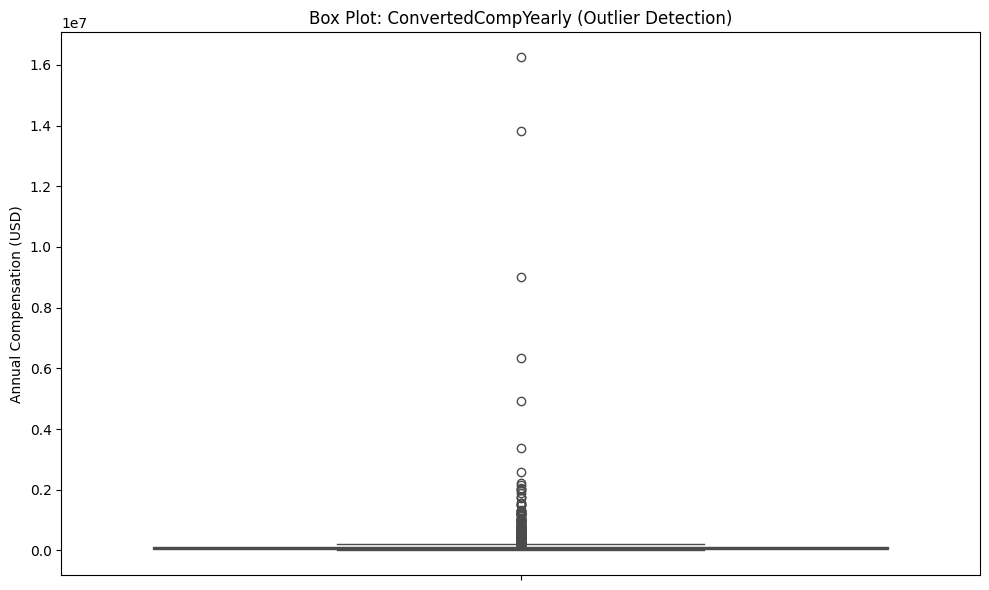

Box plot saved!


In [7]:
# Box plot to detect outliers in CompTotal
plt.figure(figsize=(10, 6))
# Use ConvertedCompYearly as it's cleaner
sns.boxplot(y=df['ConvertedCompYearly'].dropna(), color='steelblue')
plt.title('Box Plot: ConvertedCompYearly (Outlier Detection)')
plt.ylabel('Annual Compensation (USD)')
plt.tight_layout()
plt.savefig('comp_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Box plot saved!")

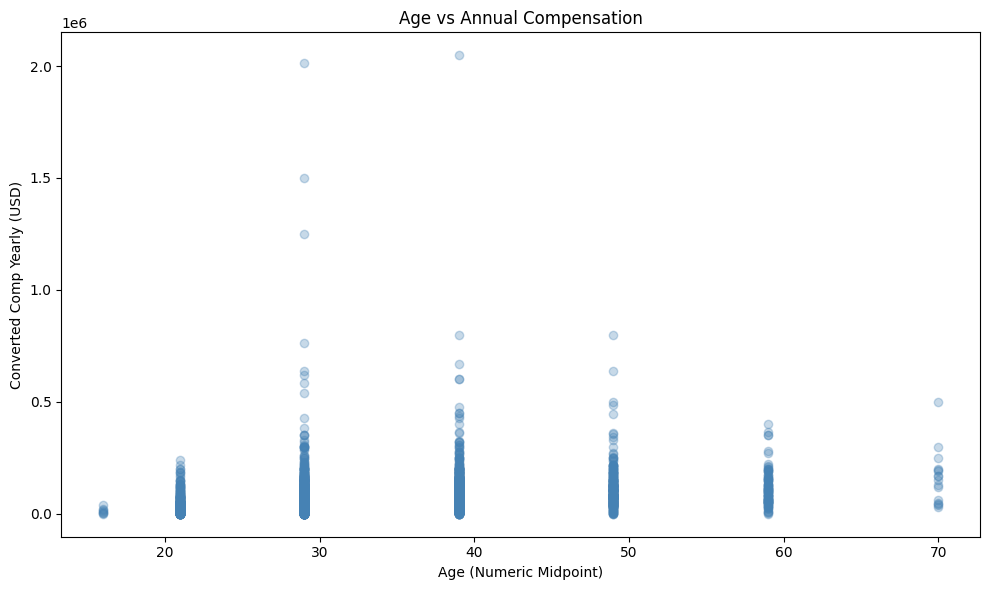

 Scatter plot saved!


In [8]:
# Map age groups to numeric midpoints
age_mapping = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 70,
    'Prefer not to say': None
}
df['Age_Numeric'] = df['Age'].map(age_mapping)

# Scatter plot Age vs CompTotal
sample = df[['Age_Numeric', 'ConvertedCompYearly']].dropna().sample(3000, random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(sample['Age_Numeric'], sample['ConvertedCompYearly'], 
            alpha=0.3, color='steelblue')
plt.title('Age vs Annual Compensation')
plt.xlabel('Age (Numeric Midpoint)')
plt.ylabel('Converted Comp Yearly (USD)')
plt.tight_layout()
plt.savefig('age_vs_comp_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Scatter plot saved!")

Correlation Matrix:
                     Age_Numeric  CompTotal  YearsCodePro  \
Age_Numeric                1.000     -0.004         0.813   
CompTotal                 -0.004      1.000        -0.009   
YearsCodePro               0.813     -0.009         1.000   
ConvertedCompYearly        0.121      0.080         0.136   
JobSat                     0.057      0.006         0.082   

                     ConvertedCompYearly  JobSat  
Age_Numeric                        0.121   0.057  
CompTotal                          0.080   0.006  
YearsCodePro                       0.136   0.082  
ConvertedCompYearly                1.000   0.037  
JobSat                             0.037   1.000  


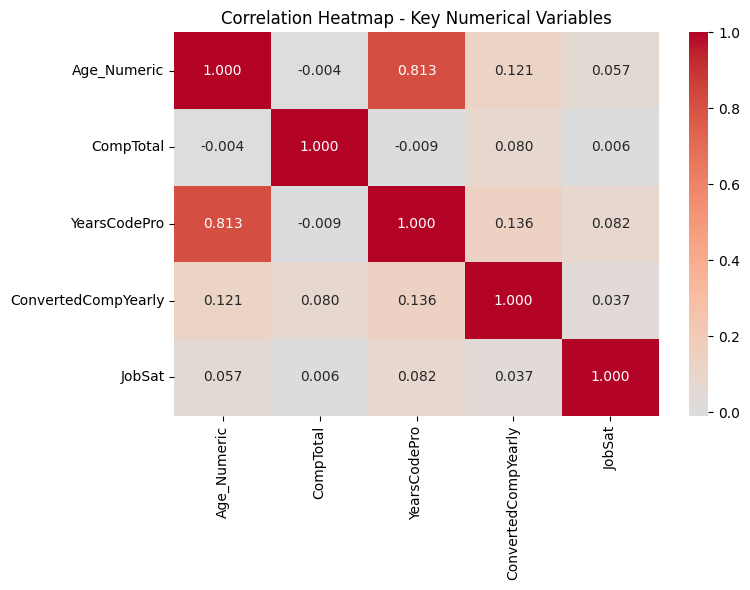

Correlation heatmap saved!


In [9]:
# Compute correlation between Age_Numeric, CompTotal and YearsCodePro
corr_df = df[['Age_Numeric', 'CompTotal', 'YearsCodePro', 
              'ConvertedCompYearly', 'JobSat']].dropna()

print("Correlation Matrix:")
print(corr_df.corr().round(3))

# Heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, fmt='.3f', 
            cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Key Numerical Variables')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved!")

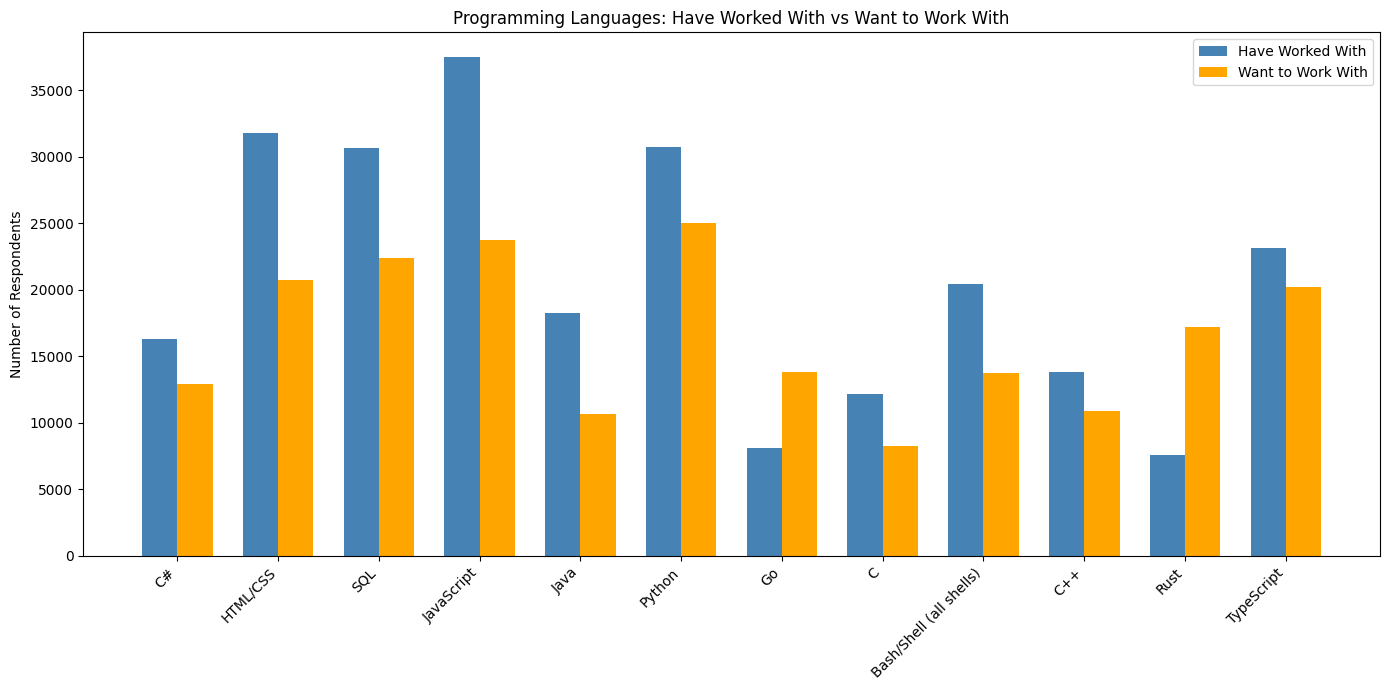

Languages comparison saved!


In [10]:
# Compare LanguageHaveWorkedWith vs LanguageWantToWorkWith
have_worked = df['LanguageHaveWorkedWith'].dropna().str.split(';').explode()
want_to_work = df['LanguageWantToWorkWith'].dropna().str.split(';').explode()

top_have = have_worked.value_counts().head(10)
top_want = want_to_work.value_counts().head(10)

# Grouped bar chart
all_langs = list(set(top_have.index) | set(top_want.index))
have_counts = [have_worked.value_counts().get(l, 0) for l in all_langs]
want_counts = [want_to_work.value_counts().get(l, 0) for l in all_langs]

x = np.arange(len(all_langs))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(x - width/2, have_counts, width, label='Have Worked With', color='steelblue')
ax.bar(x + width/2, want_counts, width, label='Want to Work With', color='orange')
ax.set_title('Programming Languages: Have Worked With vs Want to Work With')
ax.set_xticks(x)
ax.set_xticklabels(all_langs, rotation=45, ha='right')
ax.set_ylabel('Number of Respondents')
ax.legend()
plt.tight_layout()
plt.savefig('languages_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Languages comparison saved!")

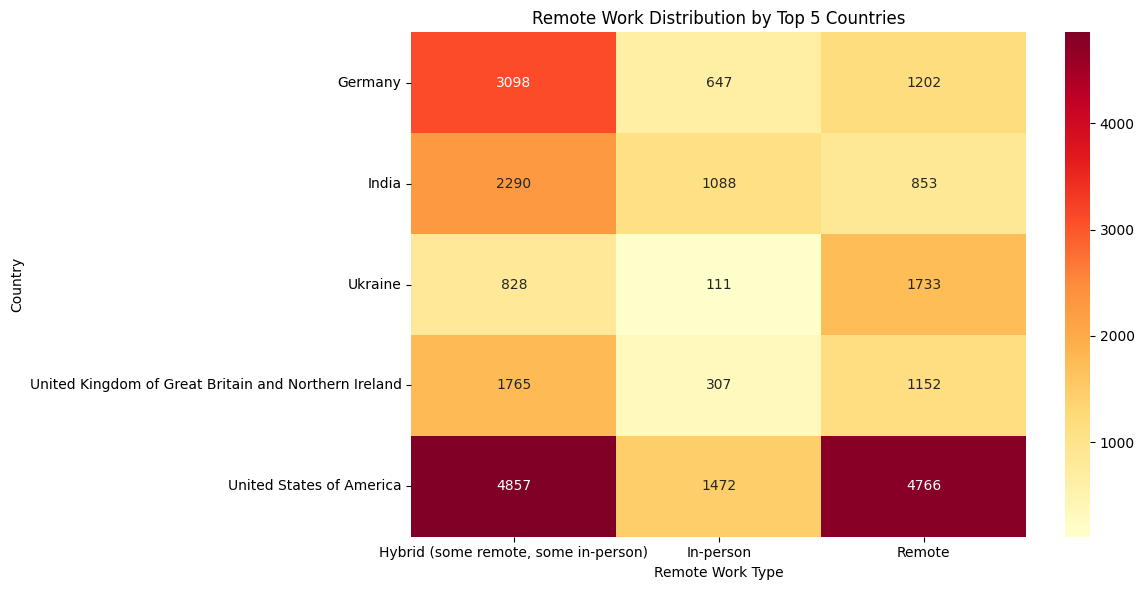

Remote work by region saved!


In [11]:
# Remote work distribution by top 5 countries
top_countries = df['Country'].value_counts().head(5).index
df_filtered = df[df['Country'].isin(top_countries)]

remote_country = pd.crosstab(df_filtered['Country'], df_filtered['RemoteWork'])

# Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(remote_country, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Remote Work Distribution by Top 5 Countries')
plt.xlabel('Remote Work Type')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('remote_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("Remote work by region saved!")

Correlation: JobSat vs YearsCodePro
  Pearson:  r = 0.0708, p-value = 0.0000
  Spearman: r = 0.0837, p-value = 0.0000


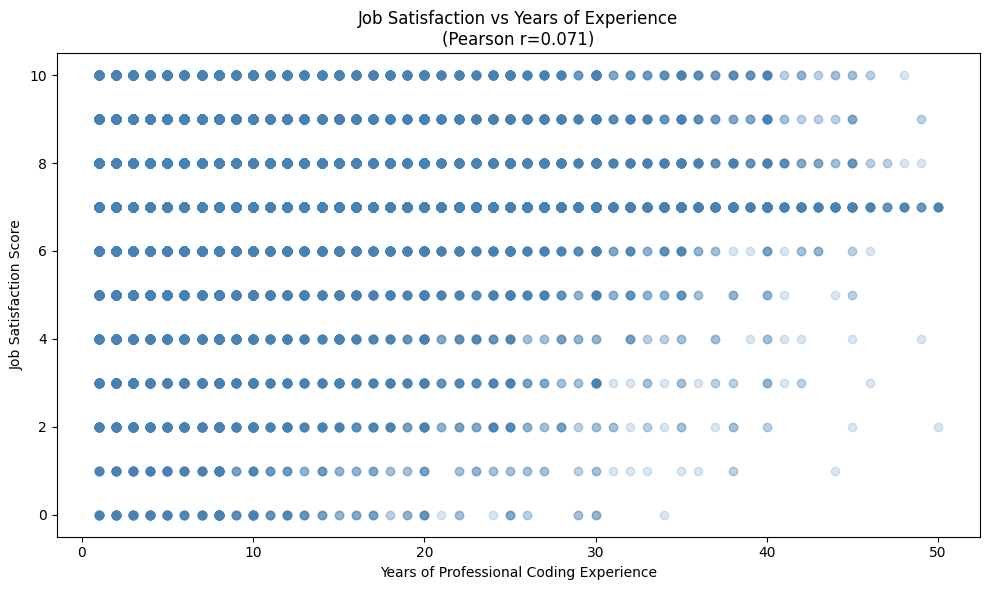

Correlation plot saved!


In [12]:
# Pearson and Spearman correlation
pearson_corr, pearson_p = stats.pearsonr(
    df['JobSat'].dropna(), 
    df['YearsCodePro'][df['JobSat'].notna()]
)
spearman_corr, spearman_p = stats.spearmanr(
    df['JobSat'].dropna(), 
    df['YearsCodePro'][df['JobSat'].notna()]
)

print("Correlation: JobSat vs YearsCodePro")
print(f"  Pearson:  r = {pearson_corr:.4f}, p-value = {pearson_p:.4f}")
print(f"  Spearman: r = {spearman_corr:.4f}, p-value = {spearman_p:.4f}")

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['YearsCodePro'], df['JobSat'], 
            alpha=0.2, color='steelblue')
plt.title(f'Job Satisfaction vs Years of Experience\n(Pearson r={pearson_corr:.3f})')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Job Satisfaction Score')
plt.tight_layout()
plt.savefig('jobsat_vs_experience.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation plot saved!")

Cross-tabulation (%) - EdLevel vs Employment:
Employment                                          Employed, full-time  \
EdLevel                                                                   
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                       81.2   
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                    81.2   
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                     82.7   
Secondary school (e.g. American high school, Ge...                 39.2   
Some college/university study without earning a...                 64.7   

Employment                                          Employed, full-time;Independent contractor, freelancer, or self-employed  \
EdLevel                                                                                                                        
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                                      6.7                          
Master’s degree (M.A., M.S., M.Eng., MBA, et

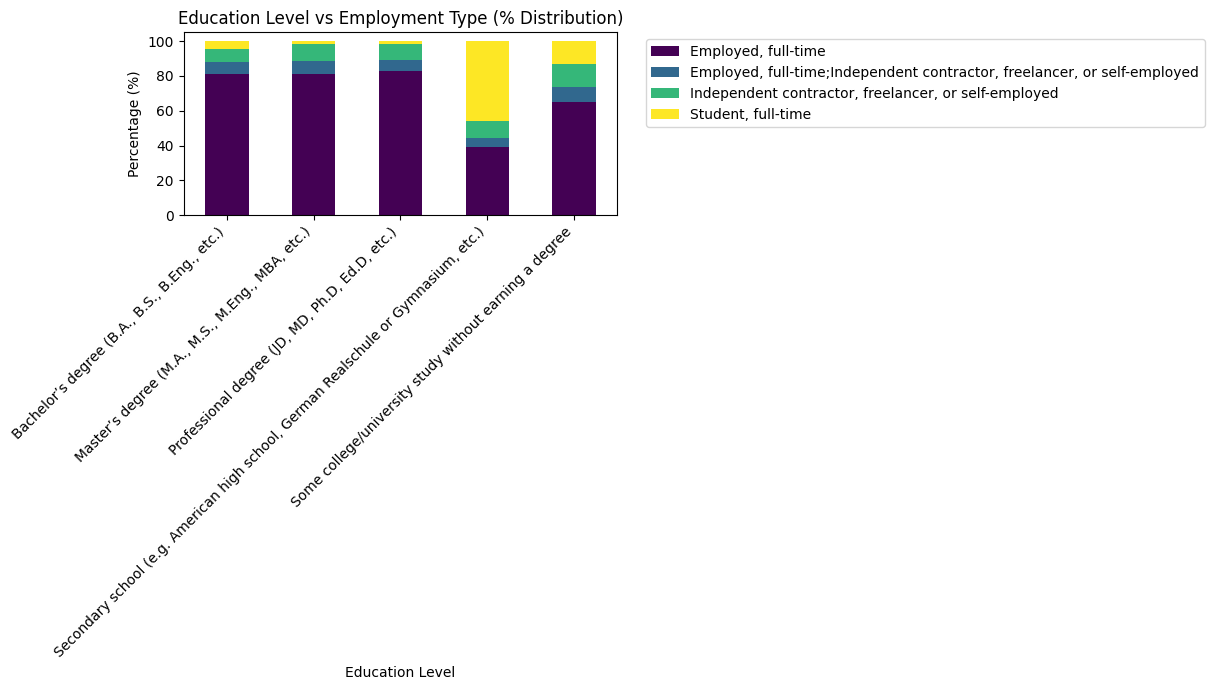

Stacked bar chart saved!


In [13]:
# Cross-tabulation EdLevel vs Employment
top_employment = df['Employment'].value_counts().head(4).index
top_edlevel = df['EdLevel'].value_counts().head(5).index

crosstab = pd.crosstab(
    df[df['EdLevel'].isin(top_edlevel)]['EdLevel'],
    df[df['Employment'].isin(top_employment)]['Employment'],
    normalize='index'  # show as percentages
) * 100

print("Cross-tabulation (%) - EdLevel vs Employment:")
print(crosstab.round(1))

# Stacked bar plot
crosstab.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Education Level vs Employment Type (% Distribution)')
plt.xlabel('Education Level')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('edlevel_vs_employment_stacked.png', dpi=150, bbox_inches='tight')
plt.show()
print("Stacked bar chart saved!")

In [14]:
# Save cleaned dataset note - skipping CSV save due to file size
print("Analysis complete - dataset not saved to CSV (too large for git)")

# Final summary
print("\n--- Lab 13 Complete Summary ---")
print(f"Total respondents: {len(df):,}")
print(f"Age & YearsCodePro correlation: 0.813 (strong)")
print(f"JobSat & YearsCodePro correlation: 0.071 (weak)")
print(f"CompTotal outliers (IQR): 28,132")
print(f"Most satisfied group: JobSat = 7.0 (42,690 respondents)")
print(f"Higher education → Full-time employment: ~81-83%")

Analysis complete - dataset not saved to CSV (too large for git)

--- Lab 13 Complete Summary ---
Total respondents: 65,437
Age & YearsCodePro correlation: 0.813 (strong)
JobSat & YearsCodePro correlation: 0.071 (weak)
CompTotal outliers (IQR): 28,132
Most satisfied group: JobSat = 7.0 (42,690 respondents)
Higher education → Full-time employment: ~81-83%
